# 1 Module, Globals und Daten

## 1.1 Module

In [4]:
##### IMPORTS #####

import numpy as np
import pandas as pd

from xgboost import XGBClassifier

import sklearn.metrics as skm
from sklearn.model_selection import train_test_split, learning_curve

from xgboost import XGBClassifier

import os

import matplotlib.pyplot as pyplot

## 1.2 Globals

In [5]:
##### Globals #####
dataPath = 'datasets/gyro/'                         # Set location of dataset


## 1.3 Daten

In [6]:
##### Data Import and Splitting #####
data = pd.read_csv(dataPath + 'gyro_mobile.csv')    # Dataset is imbalanced with only ~1.7% of all labels being 0's
data = data.drop(columns='timestamp')
xdata = data.iloc[:,:6]
ydata = data.iloc[:,6:]

xtrain, xtest, ytrain, ytest = train_test_split( 
    xdata,
    ydata,
    random_state=0,
    train_size=0.33,
    stratify=ydata                                  # Preserve label imbalance across train- and test datasets
)

ev_test = [(xtest,ytest)]
ev_both = [(xtest,ytest),(xtrain,ytrain)]

## 1.4 Funktionen

In [ ]:
def plotReport(model):
    global xtest, ytest
    yhat = model.predict(xtest)
    print(f'Accuracy Score: \t\t{skm.accuracy_score(ytest, yhat)}')          # 0.9828310161425772 stratified | 0.981664644956611  naive  | 0.9534384622562284 scale_pos_weight = len(0s)/len(1s)
    print(f'Balanced Accuracy-Score: \t{skm.balanced_accuracy_score(ytest, yhat)}') # 0.5990495790838934 stratified | 0.5770402535045962 naive  | 0.8314600386751905 scale_pos_weight = len(0s)/len(1s)
    print()
    print(skm.classification_report(ytest,yhat, labels=[0,1], target_names=['0: standing','1: walking']))

    skm.ConfusionMatrixDisplay.from_estimator(model, xtest, ytest, cmap='Blues', normalize='true')
    pyplot.title('')
    pyplot.show()

    skm.ConfusionMatrixDisplay.from_estimator(model, xtest, ytest, cmap="Blues" ,values_format='d')
    pyplot.show()

def plotLearningCurves(model):
    
    # https://xgboosting.com/xgboost-plot-learning-curve/

    global xtest, ytest
    
    # Calculate learning curves
    train_sizes, train_scores, test_scores = learning_curve(
    estimator=model, X=xdata, y=ydata, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.75, 1.0, 10))

    # Calculate mean and standard deviation of scores
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # Plot learning curves
    pyplot.figure(figsize=(8, 6))
    pyplot.plot(train_sizes, train_mean, color='blue', marker='o', label='Training accuracy')
    pyplot.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')
    pyplot.plot(train_sizes, test_mean, color='green', marker='+', label='Validation accuracy')
    pyplot.fill_between(train_sizes, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')
    pyplot.title('Learning Curves')
    pyplot.xlabel('Training set size')
    pyplot.ylabel('Accuracy')
    pyplot.grid()
    pyplot.legend(loc='lower right')
    pyplot.show()

def plotFeatureImportances(model):    
    iScores = model.feature_importances_
    fNames = model.feature_names_in_

    fig,ax = pyplot.subplots()
    ax.bar(fNames, iScores)
    ax.set_ylabel("Importance Scores")
    ax.set_xlabel("Features")

    pyplot.show()

def plotGeneralizationCurves(model, custom_names = None):
    results = model.evals_result()
    names = list(model.evals_result())
    lossValue = list(results[names[0]])[0]
    
    if custom_names == None:
        for i in names:
            pyplot.plot(results[i][lossValue], label=i)
    else:
        name_index = 0
        for i in names:
            pyplot.plot(results[i][lossValue], label=custom_names[name_index])
            name_index += 1

    pyplot.ylabel(lossValue)
    pyplot.xlabel('Iterations')
    pyplot.legend()
    pyplot.show()

def checkOverfitting(model):
    global xtrain, ytrain, xtest, ytest
    print("Flat Scores:")
    train_acc = skm.accuracy_score(ytrain, model.predict(xtrain))
    test_acc = skm.accuracy_score(ytest, model.predict(xtest))
    print(f'Accuracy Score mit Trainings-Datensatz: {train_acc}')
    print(f'Accuracy Score mit Test-Datensatz: {test_acc}')
    print(f'Train-Test-Difference: {train_acc - test_acc}\n')

    print("Balanced Scores:")
    train_acc = skm.balanced_accuracy_score(ytrain, model.predict(xtrain))
    test_acc = skm.balanced_accuracy_score(ytest, model.predict(xtest))
    print(f'Accuracy Score mit Trainings-Datensatz: {train_acc}')
    print(f'Accuracy Score mit Test-Datensatz: {test_acc}')
    print(f'Train-Test-Difference: {train_acc - test_acc}')

# 2 Modell

## 2.1 Naives Modell / Raw Data

Best Iteration based on Test-Data: 22
Accuracy Score: 		0.9829709806848932
Balanced Accuracy-Score: 	0.5555419742157954

              precision    recall  f1-score   support

 0: standing       0.63      0.11      0.19       383
  1: walking       0.98      1.00      0.99     21051

    accuracy                           0.98     21434
   macro avg       0.81      0.56      0.59     21434
weighted avg       0.98      0.98      0.98     21434



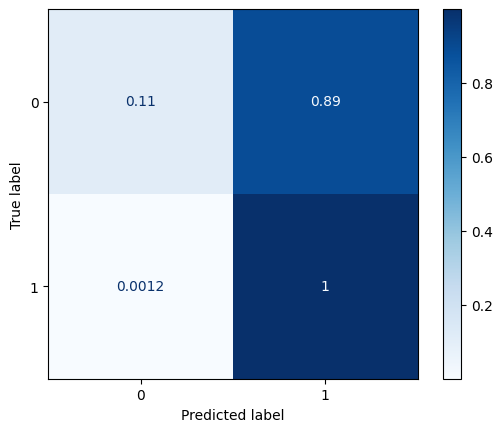

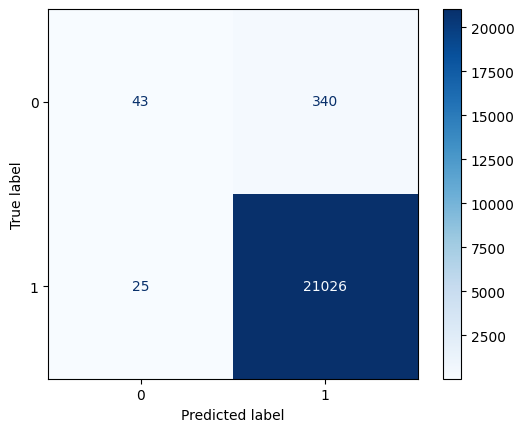

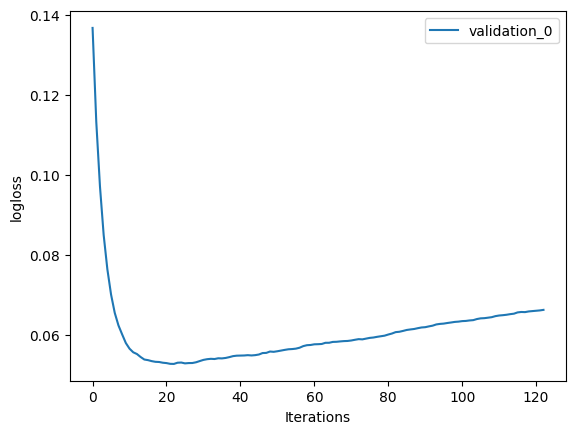

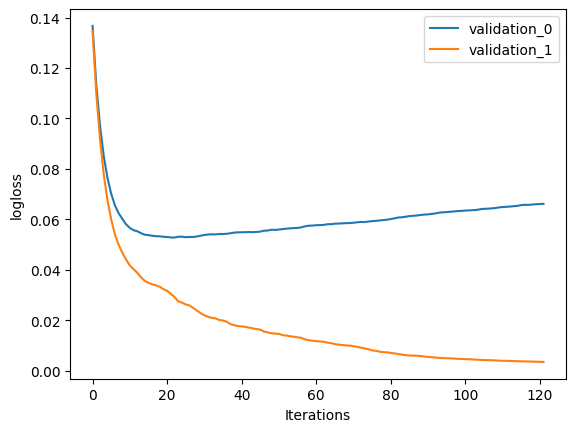

Flat Scores:
Accuracy Score mit Trainings-Datensatz: 1.0
Accuracy Score mit Test-Datensatz: 0.9833442194644023
Train-Test-Difference: 0.016655780535597686

Balanced Scores:
Accuracy Score mit Trainings-Datensatz: 1.0
Accuracy Score mit Test-Datensatz: 0.5877752686407609
Train-Test-Difference: 0.4122247313592391


In [8]:
clf_naive = XGBClassifier(
    objective = "binary:logistic",
    tree_method = 'exact',
    n_estimators = 100000,
    early_stopping_rounds = 100,
    )


clf_naive.fit(
    xtrain, ytrain,
    eval_set = ev_test,
    verbose = 0
)

print(f'Best Iteration based on Test-Data: {clf_naive.best_iteration}')
plotReport(clf_naive)
plotGeneralizationCurves(clf_naive)

new_n_estimators = clf_naive.early_stopping_rounds + clf_naive.best_iteration

clf_naive.set_params(
    n_estimators = new_n_estimators,
    early_stopping_rounds = None
)
clf_naive.fit(
    xtrain, ytrain,
    eval_set = ev_both,
    verbose = 0
)
plotGeneralizationCurves(clf_naive)
checkOverfitting(clf_naive)

## 2.2 Angepasstes Modell: Skalierte Klassen

[XGBoost for Imbalanced Classification](https://xgboosting.com/xgboost-scale_pos_weight-vs-sample_weight-for-imbalanced-classification/)

Best Iteration based on Test-Data: 1155
Accuracy Score: 		0.9732201175702155
Balanced Accuracy-Score: 	0.7146394315533344

              precision    recall  f1-score   support

 0: standing       0.32      0.45      0.37       383
  1: walking       0.99      0.98      0.99     21051

    accuracy                           0.97     21434
   macro avg       0.66      0.71      0.68     21434
weighted avg       0.98      0.97      0.98     21434



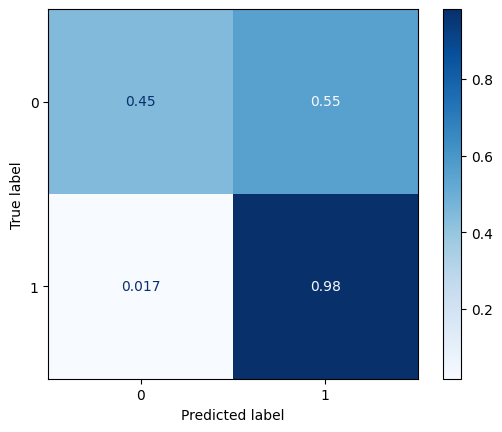

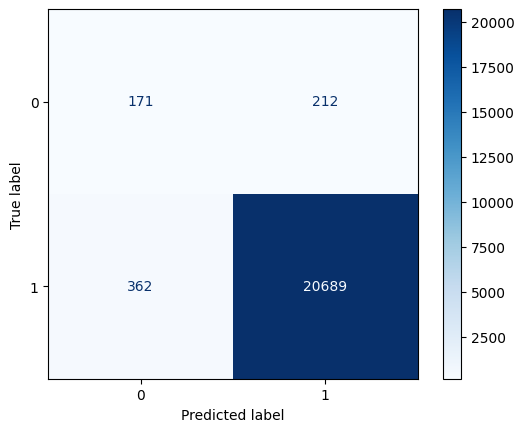

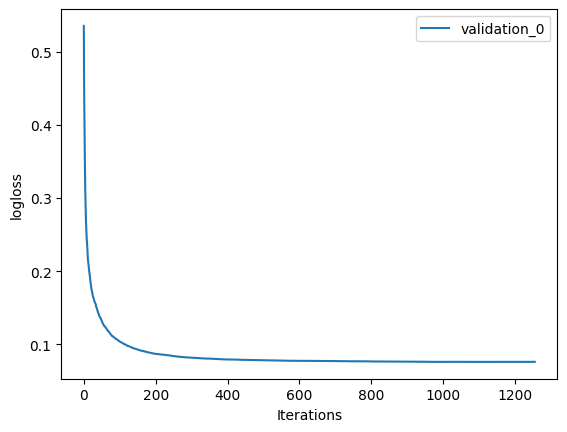

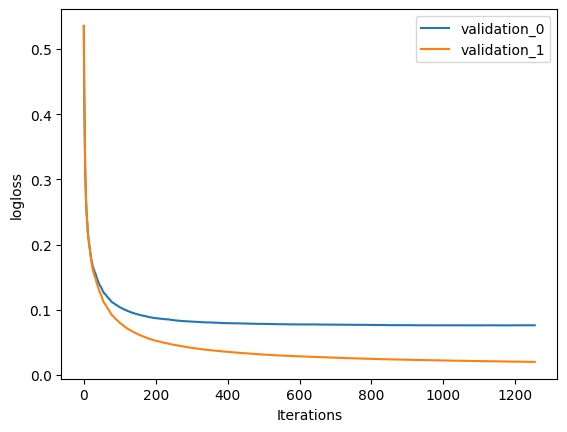

Flat Scores:
Accuracy Score mit Trainings-Datensatz: 0.9951690821256038
Accuracy Score mit Test-Datensatz: 0.9734533918074088
Train-Test-Difference: 0.02171569031819509

Balanced Scores:
Accuracy Score mit Trainings-Datensatz: 0.9975407464557817
Accuracy Score mit Test-Datensatz: 0.7109129971933138
Train-Test-Difference: 0.2866277492624679


In [9]:
classratio = len(data[data['Activity']==0]) / len(data[data['Activity']==1])

clf_scaled = XGBClassifier(
    objective = "binary:logistic",
    tree_method = 'exact',
    scale_pos_weight = classratio, # Increase weight of minority class
    n_estimators = 100000,
    early_stopping_rounds = 100,
)

clf_scaled.fit(xtrain,ytrain,
               eval_set=ev_test,
               verbose = 0)

print(f'Best Iteration based on Test-Data: {clf_scaled.best_iteration}')
plotReport(clf_scaled)
plotGeneralizationCurves(clf_scaled)

new_n_estimators = clf_scaled.early_stopping_rounds + clf_scaled.best_iteration

bestIteration = clf_scaled.best_iteration

clf_scaled.set_params(
    n_estimators = new_n_estimators,
    early_stopping_rounds = None
)
clf_scaled.fit(
    xtrain, ytrain,
    eval_set = ev_both,
    verbose = 0
)
plotGeneralizationCurves(clf_scaled)
checkOverfitting(clf_scaled)

## 2.2 Skaliertes Modell mit Best Iteration

Amount of Estimators: 		1155
Accuracy Score: 		0.9733134272650928
Balanced Accuracy-Score: 	0.7146869352348697

              precision    recall  f1-score   support

 0: standing       0.32      0.45      0.37       383
  1: walking       0.99      0.98      0.99     21051

    accuracy                           0.97     21434
   macro avg       0.66      0.71      0.68     21434
weighted avg       0.98      0.97      0.98     21434



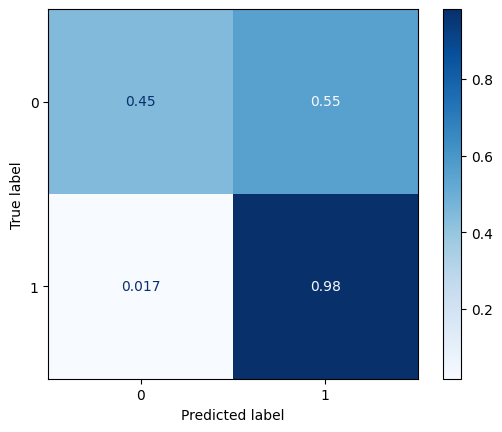

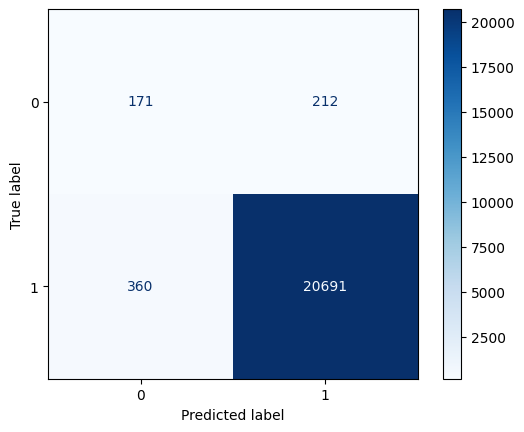

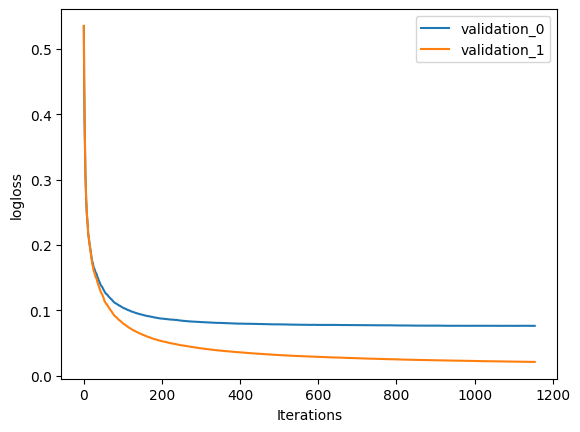

Flat Scores:
Accuracy Score mit Trainings-Datensatz: 0.9951690821256038
Accuracy Score mit Test-Datensatz: 0.9734533918074088
Train-Test-Difference: 0.02171569031819509

Balanced Scores:
Accuracy Score mit Trainings-Datensatz: 0.9975407464557817
Accuracy Score mit Test-Datensatz: 0.7109129971933138
Train-Test-Difference: 0.2866277492624679


In [10]:
clf_scaled_bi = XGBClassifier(
    objective = "binary:logistic",
    tree_method = 'exact',
    scale_pos_weight = classratio, # Increase weight of minority class
    n_estimators = bestIteration,
    )

clf_scaled_bi.fit(
    xtrain, ytrain,
    eval_set = ev_both,
    verbose = 0
)
print(f'Amount of Estimators: \t\t{bestIteration}')
plotReport(clf_scaled_bi)
plotGeneralizationCurves(clf_scaled_bi)
checkOverfitting(clf_scaled)

## 2.4 Modellverhalten & -größe bei variierender Baumtiefe

### 2.4.1 Modelle erzeugen und Daten sammeln

In [11]:
bestIterList = []
accList = []
ubjSizeList = []
jsonSizeList = []

maximum = 30

for i in range(1,maximum+1):
    clf_iter = XGBClassifier(objective = "binary:logistic",
                            tree_method = 'exact',
                            scale_pos_weight = classratio, # Increase weight of minority class 
                            n_estimators = 100000,
                            early_stopping_rounds = 50,
                            max_depth = i
                            )

    clf_iter.fit(xtrain,ytrain,
                eval_set=ev_test,
                verbose = 0
                )

    bestIter_local = clf_iter.best_iteration
    acc_local = skm.accuracy_score(ytest,clf_iter.predict(xtest, iteration_range=(0,clf_iter.best_iteration)))
    
    clf_iter = XGBClassifier(objective = "binary:logistic",
                            tree_method = 'exact',
                            scale_pos_weight = classratio, # Increase weight of minority class 
                            n_estimators = bestIter_local,
                            early_stopping_rounds = None,
                            max_depth = i
                            )

    clf_iter.fit(xtrain,ytrain,
                eval_set=ev_test,
                verbose = 0
                )

    clf_iter.save_model('clf_iter.ubjson')
    clf_iter.save_model('clf_iter.json')
    
    ubjSizeList.append(os.path.getsize('clf_iter.ubjson'))
    jsonSizeList.append(os.path.getsize('clf_iter.json'))
    bestIterList.append(bestIter_local)
    accList.append(acc_local)

/home/denis/arduino-xgboost/.venv/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [13:14:06] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)
/home/denis/arduino-xgboost/.venv/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [13:14:14] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)
/home/denis/arduino-xgboost/.venv/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [13:14:19] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)
/home/denis/arduino-xgboost/.venv/lib/py

### 2.4.2 Gesammelte Daten visualisieren

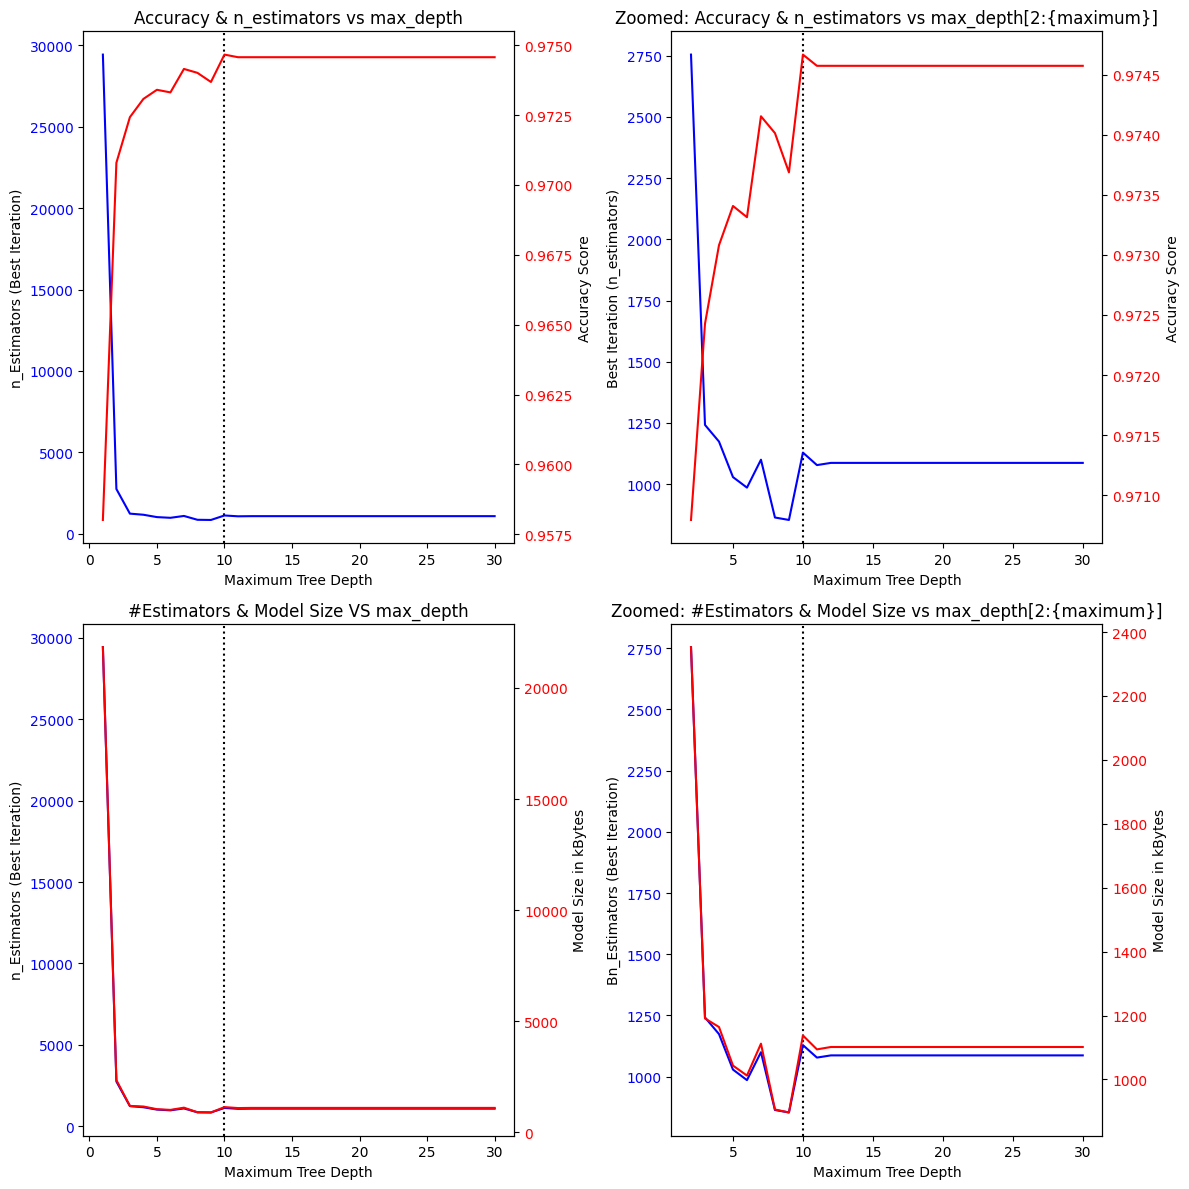

In [12]:
# Plot Accuracy vs Complexity

ubjSizeList_kB = [x/1024 for x in ubjSizeList]

fig, ax = pyplot.subplots(2,2)

fig.set_figwidth(12)
fig.set_figheight(12)

##### OBEN LINKS #####

ax[0][0].set_title("Accuracy & n_estimators vs max_depth")

ax[0][0].axvline(x=10, color="black", linestyle=":")

ax[0][0].set_xlabel("Maximum Tree Depth")
ax[0][0].set_ylabel("n_Estimators (Best Iteration)")
ax[0][0].tick_params(axis='y', labelcolor="blue")
ax[0][0].plot(range(1,maximum+1),bestIterList,color="blue")

ax10_twin = ax[0][0].twinx()

ax10_twin.set_ylabel("Accuracy Score")
ax10_twin.tick_params(axis='y', labelcolor="red")
ax10_twin.plot(range(1,maximum+1),accList,color="red")

##### OBEN RECHTS #####

ax[0][1].set_title("Zoomed: Accuracy & n_estimators vs max_depth[2:{maximum}]")

ax[0][1].axvline(x=10, color="black", linestyle=":")

ax[0][1].set_xlabel("Maximum Tree Depth")
ax[0][1].set_ylabel("Best Iteration (n_estimators)")
ax[0][1].tick_params(axis='y', labelcolor="blue")
ax[0][1].plot(range(2,maximum+1),bestIterList[1:],color="blue")

ax11_twin = ax[0][1].twinx()

ax11_twin.set_ylabel("Accuracy Score")
ax11_twin.tick_params(axis='y', labelcolor="red")
ax11_twin.plot(range(2,maximum+1),accList[1:],color="red")

##### UNTEN LINKS #####

ax[1][0].set_title("#Estimators & Model Size VS max_depth")

ax[1][0].axvline(x=10, color="black", linestyle=":")

ax[1][0].set_xlabel("Maximum Tree Depth")
ax[1][0].set_ylabel("n_Estimators (Best Iteration)")
ax[1][0].tick_params(axis='y', labelcolor="blue")
ax[1][0].plot(range(1,maximum+1),bestIterList,color="blue")

ax00_twin = ax[1][0].twinx()

ax00_twin.set_ylabel("Model Size in kBytes")
ax00_twin.tick_params(axis='y', labelcolor="red")
ax00_twin.plot(range(1,maximum+1),ubjSizeList_kB,color="red")

##### UNTEN RECHTS #####

ax[1][1].set_title("Zoomed: #Estimators & Model Size vs max_depth[2:{maximum}]")
# ax[1][1].set_title("Zoomed: #Estimators & Model Size vs max_depth[3:15]")

ax[1][1].axvline(x=10, color="black", linestyle=":")

ax[1][1].set_xlabel("Maximum Tree Depth")
ax[1][1].set_ylabel("Bn_Estimators (Best Iteration)")
ax[1][1].tick_params(axis='y', labelcolor="blue")
ax[1][1].plot(range(2,maximum+1),bestIterList[1:],color="blue")
# ax[1][1].plot(range(3,maximum+1),bestIterList[2:],color="blue")

ax01_twin = ax[1][1].twinx()

ax01_twin.set_ylabel("Model Size in kBytes")
ax01_twin.tick_params(axis='y', labelcolor="red")
ax01_twin.plot(range(2,maximum+1),ubjSizeList_kB[1:],color="red")
# ax01_twin.plot(range(3,maximum+1),ubjSizeList_kB[2:],color="red")

##### PLOT THAT THING #####

fig.tight_layout()
pyplot.show()


## 2.2.5 Basismodell mit Best Iteration und max_depth

Accuracy Score: 		0.9746664178408136
Balanced Accuracy-Score: 	0.7230661257448496

              precision    recall  f1-score   support

 0: standing       0.34      0.46      0.39       383
  1: walking       0.99      0.98      0.99     21051

    accuracy                           0.97     21434
   macro avg       0.67      0.72      0.69     21434
weighted avg       0.98      0.97      0.98     21434



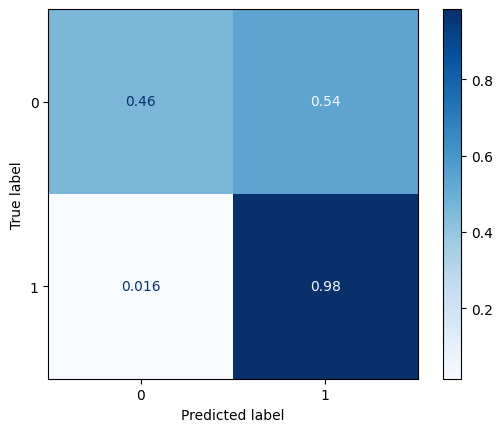

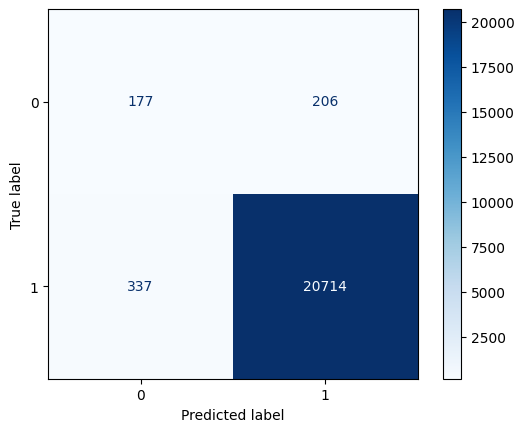

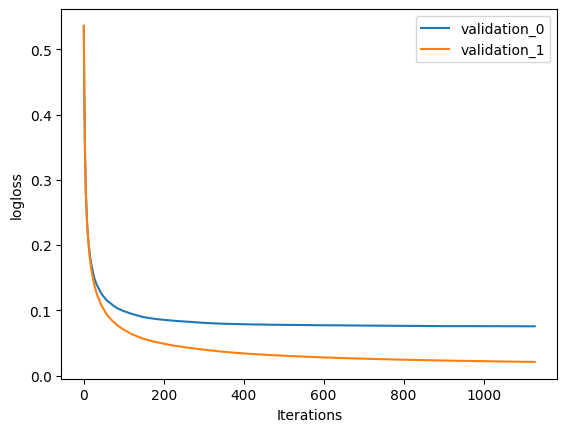

Accuracy Score on Testdata: 			0.9746664178408136
Accuracy Score on Trainingdata: 		0.9946007388462631
Accuracy Difference between Training and Test: 	0.01993432100544945
Balanced Accuracy Score on Testdata: 			0.7230661257448496
Balanced Accuracy Score on Trainingdata: 		0.997251422509403
Balanced Accuracy Difference between Training and Test:	0.2741852967645534


In [13]:
final_depth = 10

clf_final = XGBClassifier(objective = "binary:logistic",
                            tree_method = 'exact',
                            scale_pos_weight = classratio, # Increase weight of minority class 
                            n_estimators = bestIterList[final_depth-1],
                            max_depth = final_depth
                            )

clf_final.fit(xtrain,ytrain,
              eval_set=ev_both,
              verbose = 0
              )

print(f'Anzahl Estimators: {final_depth}')

plotReport(clf_final)
plotGeneralizationCurves(clf_final)

print(f'Accuracy Score on Testdata: \t\t\t{skm.accuracy_score(ytest, clf_final.predict(xtest))}')
print(f'Accuracy Score on Trainingdata: \t\t{skm.accuracy_score(ytrain, clf_final.predict(xtrain))}')
print(f'Accuracy Difference between Training and Test: \t{skm.accuracy_score(ytrain, clf_final.predict(xtrain)) - skm.accuracy_score(ytest, clf_final.predict(xtest))}')

print(f'Balanced Accuracy Score on Testdata: \t\t\t{skm.balanced_accuracy_score(ytest, clf_final.predict(xtest))}')
print(f'Balanced Accuracy Score on Trainingdata: \t\t{skm.balanced_accuracy_score(ytrain, clf_final.predict(xtrain))}')
print(f'Balanced Accuracy Difference between Training and Test:\t{skm.balanced_accuracy_score(ytrain, clf_final.predict(xtrain)) - skm.balanced_accuracy_score(ytest, clf_final.predict(xtest))}')

# Cross-Validated Learning Curves

Besser geeignet, wenn die Klassen nicht so pervers unausgeglichen sind

In [14]:
# es_clf = XGBClassifier()

# es_clf.set_params(    
#     tree_method = 'exact',
#     scale_pos_weight = classratio, # Increase weight of minority class
#     n_estimators = 10000,
#     early_stopping_rounds = 50,
#     max_depth = 2,
#     random_state = 0
# )

# es_clf.fit(
#     xtrain,ytrain,
#     eval_set = evalset,
#     verbose = 0
# )

# printLossCurves(es_clf,["Training","Test"])

# Sonstiges/Eingestellt

## Skalierung der Daten

Es wurde neben dem eigentlichem Datensatz auch Modell mit einem Datensatz trainiert, bei dem die Daten nicht skaliert worden sind.
Die daraus resultierende Accuracy war identisch mit der unskalierten Version.


In [15]:
# ##### Scaled comparison #####

# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# xdata_scaled = scaler.fit_transform(xdata)

# xtrain_scaled, xtest_scaled, ytrain_scaled, ytest_scaled = train_test_split( 
#     xdata_scaled,
#     ydata,
#     random_state=0,
#     stratify=ydata                                  # Preserve label imbalance across train- and test datasets
# )

# model_scaled = XGBClassifier(
#     objective='binary:logistic'
# )
# model_scaled.fit(xtrain_scaled,ytrain)

# yhat_scaled = model_scaled.predict(xtest_scaled)
# print(accuracy_score(ytest_scaled, yhat_scaled))    # 0.9834958739684921

## C-Reports und C-Matrizen für unterschiedliche Tree_Methods

### Raw

In [16]:
# model.set_params(tree_method = 'approx')
# model.fit(xtrain, ytrain,
#           eval_set=evalset,
#           verbose = 0)

# ##### Predictions and Accuracy #####
# yhat = model.predict(xtest)

# print(f'Accuracy Score: \t\t{skm.accuracy_score(ytest, yhat)}')          # 0.9828310161425772 stratified | 0.981664644956611  naive  | 0.9534384622562284 scale_pos_weight = len(0s)/len(1s)
# print(f'Balanced Accuracy-Score: \t{skm.balanced_accuracy_score(ytest, yhat)}') # 0.5990495790838934 stratified | 0.5770402535045962 naive  | 0.8314600386751905 scale_pos_weight = len(0s)/len(1s)
# print()
# print(skm.classification_report(ytest,yhat, labels=[0,1], target_names=['0: standing','1: walking']))

# skm.ConfusionMatrixDisplay.from_estimator(model, xtest, ytest, cmap='Blues', values_format='d')
# pyplot.show()


In [17]:
# model.set_params(tree_method = 'hist')
# model.fit(xtrain, ytrain,
#           eval_set=evalset,
#           verbose = 0)

# ##### Predictions and Accuracy #####
# yhat = model.predict(xtest)

# print(f'Accuracy Score: \t\t{skm.accuracy_score(ytest, yhat)}')          # 0.9828310161425772 stratified | 0.981664644956611  naive  | 0.9534384622562284 scale_pos_weight = len(0s)/len(1s)
# print(f'Balanced Accuracy-Score: \t{skm.balanced_accuracy_score(ytest, yhat)}') # 0.5990495790838934 stratified | 0.5770402535045962 naive  | 0.8314600386751905 scale_pos_weight = len(0s)/len(1s)
# print()
# print(skm.classification_report(ytest,yhat, labels=[0,1], target_names=['0: standing','1: walking']))

# skm.ConfusionMatrixDisplay.from_estimator(model, xtest, ytest, cmap='Blues', values_format='d')
# pyplot.show()

### Angepasst

In [18]:
# model.set_params(    
#     tree_method = 'approx',
#     scale_pos_weight = classratio, # Increase weight of minority class
#     max_delta_step = 1                                                                  # Limit the maximum change in the predictions)
# )

# model.fit(xtrain,ytrain,
#           eval_set=evalset,
#           verbose = 0)

# yhat = model.predict(xtest)

# print(f'Accuracy Score: \t\t{skm.accuracy_score(ytest, yhat)}')          # 0.9828310161425772 stratified | 0.981664644956611  naive  | 0.9534384622562284 scale_pos_weight = len(0s)/len(1s)
# print(f'Balanced Accuracy-Score: \t{skm.balanced_accuracy_score(ytest, yhat)}') # 0.5990495790838934 stratified | 0.5770402535045962 naive  | 0.8314600386751905 scale_pos_weight = len(0s)/len(1s)
# print()
# print(skm.classification_report(ytest,yhat, labels=[0,1], target_names=['0: standing','1: walking']))

# skm.ConfusionMatrixDisplay.from_estimator(model, xtest, ytest, cmap='Blues', values_format='d')
# pyplot.show()


In [19]:
# model.set_params(    
#     tree_method = 'hist',
#     scale_pos_weight = classratio, # Increase weight of minority class
#     max_delta_step = 0
# )

# model.fit(xtrain,ytrain,
#           eval_set=evalset,
#           verbose = 0)

# yhat = model.predict(xtest)

# print(f'Accuracy Score: \t\t{skm.accuracy_score(ytest, yhat)}')          # 0.9828310161425772 stratified | 0.981664644956611  naive  | 0.9534384622562284 scale_pos_weight = len(0s)/len(1s)
# print(f'Balanced Accuracy-Score: \t{skm.balanced_accuracy_score(ytest, yhat)}') # 0.5990495790838934 stratified | 0.5770402535045962 naive  | 0.8314600386751905 scale_pos_weight = len(0s)/len(1s)
# print()
# print(skm.classification_report(ytest,yhat, labels=[0,1], target_names=['0: standing','1: walking']))

# skm.ConfusionMatrixDisplay.from_estimator(model, xtest, ytest, cmap='Blues', values_format='d')
# pyplot.show()


### Validieren, dass tree_method "auto" == "hist"

In [20]:
# model = XGBClassifier()
# model.set_params(tree_method = 'auto',
#                  objective = "binary:logistic",
#                  scale_pos_weight = classratio)
# model.fit(xtrain, ytrain)

# yhat = model.predict(xtest)

# print(f'Accuracy Score: \t\t{skm.accuracy_score(ytest, yhat)}')          
# print(f'Balanced Accuracy-Score: \t{skm.balanced_accuracy_score(ytest, yhat)}')

# # Accuracy Score: 		    0.9534384622562284
# # Balanced Accuracy-Score: 	0.8314600386751905

# C-Matrix Optionen

In [21]:
# Gibt das Verhältnis von richtig und falsch bzgl. einer Vorhersage an
# skm.ConfusionMatrixDisplay.from_estimator(model, xtest, ytest, cmap='Blues', normalize='pred')
# pyplot.title('Normalize = Pred')
# pyplot.show()

# Gibt das Verhältnis der jeweiligen TP/FP/TN/FN aus allen Vorhersagen an
# skm.ConfusionMatrixDisplay.from_estimator(model, xtest, ytest, cmap='Blues', normalize='all')
# pyplot.title('Normalize = All')
# pyplot.show()